In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 6 — Simulador de eventos com múltiplas filas

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. Exercício 6 **→ você está aqui**
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

In [4]:
# Estruturas definidas na seção de outro exercício do notebook
# único, reimportadas aqui para este notebook rodar sozinho.
from src.bst import BinarySearchTree

---
# Exercício 6 — Simulador de eventos com múltiplas filas

## Enunciado
Simulador com 4 filas A–D: minúscula é chegada, maiúscula é saída, caractere não
alfabético dispara snapshot. Identificador sequencial por fila, overflow e
underflow registram erro **com contexto** e a simulação continua. Clientes
atendidos indexados em BST com busca e listagem in-order.

## Implementação — `src/simulator.py`

**Decisão de projeto 1 — a chave do índice é o identificador completo, como
objeto e não como texto.** Se a chave fosse a string `"B17"`, a travessia
in-order devolveria `B1, B10, B11, …, B2, B20`, porque a ordem de texto compara
caractere a caractere. **Um índice cuja listagem "em ordem" sai fora de ordem não
serve para auditoria** — que é a razão de o enunciado pedir o índice.

**Decisão de projeto 2 — o contador de sequência só avança em chegada
bem-sucedida.** Se um overflow consumisse o número, `B17` passaria a significar
"o 17º que *tentou* entrar" e a listagem teria buracos sem explicação.

In [5]:
from src.simulator import (COST_TABLE as COST_SIM, CheckoutSimulator, ClientId,
                           bench_index_shape, bench_simulation, find_client,
                           generate_events, list_served, list_served_by_queue)

# a ordem do identificador: B2 < B17, ao contrário do texto
assert ClientId("B", 2) < ClientId("B", 17)
assert "B17" < "B2"   # a ordem de TEXTO diria o contrário
print(f'str(ClientId("B", 17)) = {str(ClientId("B", 17))!r}   e   ClientId("B",2) < ClientId("B",17) = '
      f'{ClientId("B", 2) < ClientId("B", 17)}')

# a demonstração do problema que a decisão evita
ids = [f"B{n}" for n in range(1, 21)]
como_texto = list(BinarySearchTree(ids))
como_objeto = [str(k) for k in BinarySearchTree([ClientId.parse(t) for t in ids])]
print(f"\n  chave como STRING : {como_texto[:6]} ...  ← fora de ordem")
print(f"  chave como OBJETO : {como_objeto[:6]} ...  ← correto")

simulador = CheckoutSimulator(capacity=3)
resultado = simulador.run("aabbAB!ccCcccc#dDDz aA")
print(f"\neventos: {resultado.events!r}")
print(f"chegadas {resultado.arrivals} · saídas {resultado.departures} · "
      f"snapshots {len(resultado.snapshots)} · erros {len(resultado.errors)}")

str(ClientId("B", 17)) = 'B17'   e   ClientId("B",2) < ClientId("B",17) = True

  chave como STRING : ['B1', 'B10', 'B11', 'B12', 'B13', 'B14'] ...  ← fora de ordem
  chave como OBJETO : ['B1', 'B2', 'B3', 'B4', 'B5', 'B6'] ...  ← correto

eventos: 'aabbAB!ccCcccc#dDDz aA'
chegadas 10 · saídas 5 · snapshots 3 · erros 4


In [6]:
print("LOG (primeiras 8 linhas)")
for entrada in resultado.log[:8]:
    print(f"  t={entrada.tick:>2} {entrada.event!r:<5} {entrada.kind:<9} {entrada.message}")

print("\nSNAPSHOTS")
for snapshot in resultado.snapshots:
    print(f"  t={snapshot.tick:>2} gatilho={snapshot.trigger!r:<5} "
          f"tamanhos={snapshot.sizes} conteúdo={snapshot.contents}")

print("\nERROS COM CONTEXTO (a simulação continuou depois de cada um)")
for erro in resultado.errors:
    print(f"  t={erro.tick:>2} {erro.event!r:<4} {erro.kind:<16} fila={erro.queue} "
          f"ocupação={erro.occupancy}")
    print(f"       {erro.message[:100]}")

print(f"\nÍNDICE (in-order): {[str(r.client) for r in list_served(resultado)]}")
print(f"busca por 'B1': {find_client(resultado, 'B1')}")
print(f"restantes nas filas: {resultado.remaining}")

LOG (primeiras 8 linhas)
  t= 1 'a'   chegada   A1 entrou na fila A (1/3)
  t= 2 'a'   chegada   A2 entrou na fila A (2/3)
  t= 3 'b'   chegada   B1 entrou na fila B (1/3)
  t= 4 'b'   chegada   B2 entrou na fila B (2/3)
  t= 5 'A'   saida     A1 atendido (ordem 1, esperou 4 instante(s))
  t= 6 'B'   saida     B1 atendido (ordem 2, esperou 3 instante(s))
  t= 7 '!'   snapshot  snapshot: 2 cliente(s) em espera
  t= 8 'c'   chegada   C1 entrou na fila C (1/3)

SNAPSHOTS
  t= 7 gatilho='!'   tamanhos={'A': 1, 'B': 1, 'C': 0, 'D': 0} conteúdo={'A': ['A2'], 'B': ['B2'], 'C': [], 'D': []}
  t=15 gatilho='#'   tamanhos={'A': 1, 'B': 1, 'C': 3, 'D': 0} conteúdo={'A': ['A2'], 'B': ['B2'], 'C': ['C2', 'C3', 'C4'], 'D': []}
  t=20 gatilho=' '   tamanhos={'A': 1, 'B': 1, 'C': 3, 'D': 0} conteúdo={'A': ['A2'], 'B': ['B2'], 'C': ['C2', 'C3', 'C4'], 'D': []}

ERROS COM CONTEXTO (a simulação continuou depois de cada um)
  t=13 'c'  overflow         fila=C ocupação=3
       chegada recusada na fila C: 

In [7]:
# a listagem sai em ordem NUMÉRICA por fila, não lexicográfica
longa = CheckoutSimulator(capacity=20).run("a" * 12 + "A" * 12 + "b" * 3 + "B" * 3)
atendidos = [str(r.client) for r in list_served(longa)]
assert atendidos.index("A2") < atendidos.index("A10")
print("listagem in-order:", atendidos)
print(f"  A2 vem antes de A10: {atendidos.index('A2') < atendidos.index('A10')} "
      "(a ordem de texto inverteria)")

simulacao = pd.DataFrame(bench_simulation())
mostrar(simulacao, ["n", "chegadas", "saidas", "atendidos", "snapshots", "overflow",
                    "underflow", "eventos_invalidos", "em_espera_no_fim",
                    "indice_altura", "indice_altura_ideal", "comparacoes_por_atendimento",
                    "espera_media"],
        "SIMULAÇÕES DE TAMANHO CRESCENTE")

listagem in-order: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'B1', 'B2', 'B3']
  A2 vem antes de A10: True (a ordem de texto inverteria)


SIMULAÇÕES DE TAMANHO CRESCENTE


,n,chegadas,saidas,atendidos,snapshots,overflow,underflow,eventos_invalidos,em_espera_no_fim,indice_altura,indice_altura_ideal,comparacoes_por_atendimento,espera_media
0,200,88,67,67,10,8,22,5,21,20,7,9.5970,31.5224
1,1000,434,407,407,46,52,41,20,27,104,9,52.1179,39.1941
2,5000,2067,2051,2051,258,338,178,108,16,532,12,257.7465,43.8401
3,20000,8234,8221,8221,985,1204,967,389,13,2092,14,"1,029.0140",40.9224


### Análise em Big O

| operação | custo | por quê |
|---|---|---|
| chegada (minúscula) | O(1) | `enqueue` na fila circular do ex 5 |
| saída (maiúscula) | O(h) | `dequeue` O(1) mais a inserção no índice |
| snapshot | O(q · c) | copia o conteúdo das `q` filas |
| busca por identificador | O(h) | uma descida na BST |
| listagem in-order | O(s) | visita cada atendimento uma vez |
| simulação completa | O(e + s·h) | `e` eventos mais `s` inserções no índice |

E aqui aparece um problema que a simulação cria sozinha.

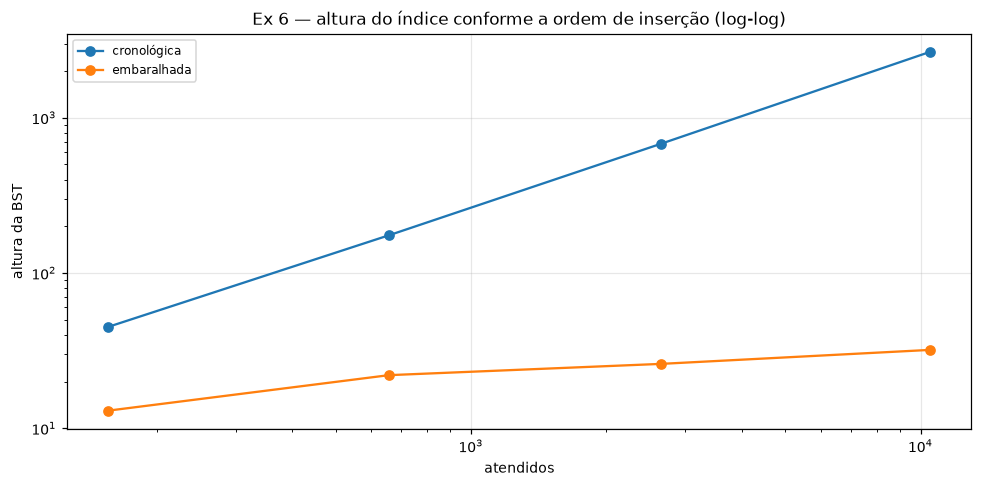

FORMA DO ÍNDICE DE ATENDIDOS — mesma informação, duas ordens de inserção


,ordem_de_insercao,atendidos,altura,altura_ideal,altura/log2s,altura/atendidos,comparacoes_construcao,comparacoes_por_insercao,comparacoes_busca
6,cronológica,10509,2656,14,198.8122,0.2527,13818516,"1,314.9221",2624
7,embaralhada,10509,32,14,2.3953,0.0030,159607,15.1876,9


In [8]:
forma_indice = pd.DataFrame(bench_index_shape())
grafico_loglog(forma_indice, "atendidos", "altura", "ordem_de_insercao",
               "Ex 6 — altura do índice conforme a ordem de inserção (log-log)",
               "ex06_indice.png", "altura da BST")
mostrar(forma_indice[forma_indice["n"] == forma_indice["n"].max()], ["ordem_de_insercao", "atendidos", "altura", "altura_ideal",
                       "altura/log2s", "altura/atendidos", "comparacoes_construcao",
                       "comparacoes_por_insercao", "comparacoes_busca"],
        "FORMA DO ÍNDICE DE ATENDIDOS — mesma informação, duas ordens de inserção")

In [9]:
crono = forma_indice[forma_indice["ordem_de_insercao"] == "cronológica"].iloc[0]
baralho = forma_indice[forma_indice["ordem_de_insercao"] == "embaralhada"].iloc[0]
veredito(
    "O índice degenera SOZINHO: os identificadores chegam crescentes dentro de cada fila\n"
    "(A1, A2, A3, …) — que é exatamente a ordem de inserção do pior caso do ex 3.\n\n"
    f"  cronológica : altura {int(crono['altura']):>4}  "
    f"({crono['altura/log2s']:.1f}× a ideal)  ·  {crono['comparacoes_por_insercao']:>6.1f} comparações/inserção  ·  "
    f"busca: {int(crono['comparacoes_busca']):>3}\n"
    f"  embaralhada : altura {int(baralho['altura']):>4}  "
    f"({baralho['altura/log2s']:.1f}× a ideal)  ·  {baralho['comparacoes_por_insercao']:>6.1f} comparações/inserção  ·  "
    f"busca: {int(baralho['comparacoes_busca']):>3}\n\n"
    f"  → {crono['altura']/baralho['altura']:.0f}× mais alta, "
    f"{crono['comparacoes_por_insercao']/baralho['comparacoes_por_insercao']:.0f}× mais cara por inserção, "
    f"{crono['comparacoes_busca']/baralho['comparacoes_busca']:.0f}× mais cara por busca.\n\n"
    "É a justificativa quantitativa para trocar a BST simples por uma auto-balanceada\n"
    "caso o volume cresça — com o número na frente, não por intuição."
)


O índice degenera SOZINHO: os identificadores chegam crescentes dentro de cada fila
(A1, A2, A3, …) — que é exatamente a ordem de inserção do pior caso do ex 3.

  cronológica : altura   45  (6.2× a ideal)  ·    20.8 comparações/inserção  ·  busca:  38
  embaralhada : altura   13  (1.8× a ideal)  ·     6.6 comparações/inserção  ·  busca:   8

  → 3× mais alta, 3× mais cara por inserção, 5× mais cara por busca.

É a justificativa quantitativa para trocar a BST simples por uma auto-balanceada
caso o volume cresça — com o número na frente, não por intuição.
